In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import machine_learning_models as mlm
pd.set_option('display.max_rows', 100)

In [11]:
df = pd.read_csv(r'C:\Users\mechz\Documents\Jobs_Analysis\job_postings.csv')
X = df.drop(columns=['salary_year_avg'])
predictors = X.columns.to_list()
numerical_columns = ['job_posted_year', 'job_posted_month_sine']
numerical_indices = X.columns.get_indexer(numerical_columns)
X = X.to_numpy()
y = np.where(df['salary_year_avg'] > df['salary_year_avg'].median(), 1, 0)

training_index, testing_index = mlm.train_test_split(X.shape[0], 10000)
X_training = X[training_index]
y_training = y[training_index]
X_testing = X[testing_index]
y_testing = y[testing_index]

for index in numerical_indices:
    mean = np.mean(X_training[:,index])
    std = np.std(X_training[:, index])
    X_training[:,index] = (X_training[:,index] - mean) / std
    X_testing[:,index] = (X_testing[:,index] - mean) / std

The mean, median, and standard deviation of the salary are 122390.906, 115000.000, and 47019.486 respectively.


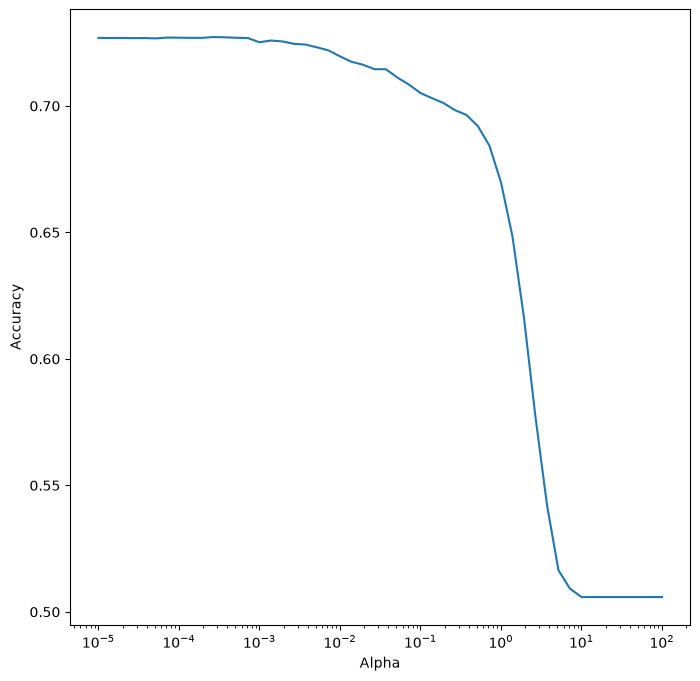

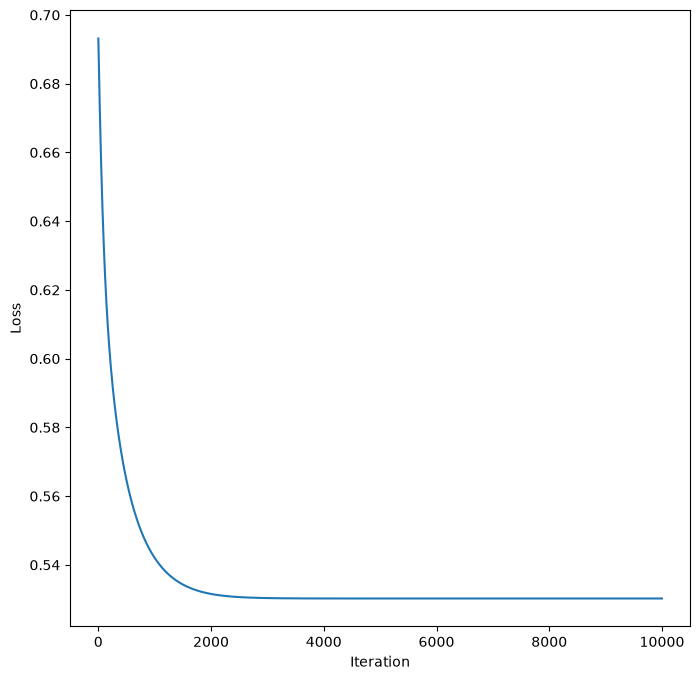

The best alpha value is 0.000 which gives a testing accuracy score of 73.270%.


,value
variable,
job_title_short_Senior Data Scientist,0.771472
job_title_short_Senior Data Engineer,0.690313
job_via_Talent.com,0.467620
job_title_short_Data Scientist,0.464245
job_via_Built In,0.457089
job_via_LinkedIn,0.436726
job_title_short_Software Engineer,0.432241
skills_snowflake,0.350623
skills_python,0.336576


The model with only job titles as predictors has an accuracy score of 70.950%.


,value
variable,
job_title_short_Senior Data Scientist,0.863973
job_title_short_Senior Data Engineer,0.843003
job_title_short_Data Scientist,0.640827
job_title_short_Data Engineer,0.615362
job_title_short_Machine Learning Engineer,0.357355
job_title_short_Software Engineer,0.285129
job_title_short_Cloud Engineer,-0.039078
intercept,-0.210568
job_title_short_Senior Data Analyst,-0.312956


The model with only skills as predictors has an accuracy score of 67.740%.


...

,value
variable,
job_country_Sudan,0.515706
job_country_Canada,0.165579
job_country_United States,0.019839
job_country_South Africa,-0.006362
intercept,-0.017227
job_country_Germany,-0.128682
job_country_United Kingdom,-0.151339
job_country_Spain,-0.325683
job_country_Poland,-0.335657


The model with only the websites as predictors has an accuracy score of 57.080%.


,value
variable,
job_via_Built In,0.741651
job_via_Talent.com,0.599949
job_via_LinkedIn,0.496168
job_via_Dice,0.115115
job_via_other,0.113759
job_via_Ladders,0.050399
intercept,-0.043570
job_via_Ai-Jobs.net,-0.096572
job_via_Indeed,-0.190421


The model with only other stuff as predictors has an accuracy score of 55.010%.


,value
variable,
job_work_from_home,0.454362
job_health_insurance,0.277463
job_posted_month_sine,0.017222
intercept,-0.000003
job_posted_year,-0.000101
job_no_degree_mention,-0.209562


In [13]:
print(f'The mean, median, and standard deviation of the salary are {np.mean(df['salary_year_avg']):.3f}, {np.median(df['salary_year_avg']):.3f}, and {np.std(df['salary_year_avg']):.3f} respectively.')

alphas = np.logspace(-5, 2, 50)
accuracies = {}
for alpha in alphas:
    accuracies_one_fold = []
    for fold in mlm.kfold_cross_validation(5, X_training.shape[0]):
        inner_model = mlm.Logistic_Regression()
        inner_model.fit(np.delete(X_training, fold, axis=0), np.delete(y_training, fold, axis=0), alpha=alpha)
        predictions = inner_model.predict(X_training[fold])
        predictions = np.array([1 if x > 0.5 else 0 for x in predictions])
        accuracy = np.sum(predictions == y_training[fold]) / len(y_training[fold])
        accuracies_one_fold.append(accuracy)
    average_accuracy = np.mean(accuracies_one_fold)
    accuracies.update({alpha:average_accuracy})
best_alpha = max(accuracies, key=accuracies.get)

fig, ax = plt.subplots(figsize=(8,8))
ax.semilogx(accuracies.keys(), accuracies.values())
ax.set_xlabel('Alpha')
ax.set_ylabel('Accuracy')
plt.show()

final_model = mlm.Logistic_Regression(max_iterations=10000, record_losses=True)
final_model.fit(X_training, y_training, alpha=best_alpha)
predictions = final_model.predict(X_testing)
predictions = np.array([1 if x > 0.5 else 0 for x in predictions])
accuracy = np.sum(predictions == y_testing) / len(y_testing)

fig, ax = plt.subplots(figsize=(8,8))
ax.plot(final_model.iterations, final_model.losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
plt.show()

print(f'The best alpha value is {best_alpha:.3f} which gives a testing accuracy score of {accuracy:.3%}.')
full_model = mlm.Logistic_Regression()
full_model.fit(X, y, alpha=best_alpha)
parameters = ['intercept'] + predictors
parameters_dictionary = dict(zip(parameters, np.insert(full_model.parameters.reshape(-1).copy(), 0, full_model.bias)))
parameters_df = pd.DataFrame([parameters_dictionary])
parameters_df = pd.melt(parameters_df).set_index('variable', drop=True).sort_values(by='value', ascending=False)
display(parameters_df)

def separate_by_category(inputted_string=None, inputted_list=None):
    if not inputted_list:
        specific_predictors = [x for x in parameters_dictionary.keys() if inputted_string in x]
    if not inputted_string:
        specific_predictors = inputted_list
    specific_model = mlm.Logistic_Regression()
    specific_X = df[specific_predictors].to_numpy()
    specific_model.fit(specific_X, y, best_alpha)
    specific_parameters = ['intercept'] + specific_predictors
    specific_parameters_dictionary = dict(zip(specific_parameters, np.insert(specific_model.parameters.reshape(-1).copy(), 0, specific_model.bias)))
    parameters_specific_df = pd.DataFrame([specific_parameters_dictionary])
    parameters_specific_df = pd.melt(parameters_specific_df).set_index('variable', drop=True)
    evaluation_model = mlm.Logistic_Regression()
    evaluation_model.fit(specific_X[training_index], y_training, alpha=best_alpha)
    predictions = evaluation_model.predict(specific_X[testing_index])
    predictions = np.array([1 if x > 0.5 else 0 for x in predictions])
    accuracy = np.sum(predictions == y_testing) / len(y_testing)
    return parameters_specific_df.sort_values(by='value', ascending=False), accuracy

parameters_specific_job_title_df, accuracy_job_title = separate_by_category(inputted_string='job_title_short')
print(f'The model with only job titles as predictors has an accuracy score of {accuracy_job_title:.3%}.')
display(parameters_specific_job_title_df)

parameters_specific_skill_df, accuracy_skill = separate_by_category(inputted_string='skill')
print(f'The model with only skills as predictors has an accuracy score of {accuracy_skill:.3%}.')
display(parameters_specific_skill_df)

job_schedule_types = ['Contractor', 'Full-time', 'Internship', 'Part-time', 'Tempwork']
parameters_specific_schedule_df, accuracy_schedule  = separate_by_category(inputted_list=job_schedule_types)
print(f'The model with only job schedule types as predictors has an accuracy score of {accuracy_schedule:.3%}.')
display(parameters_specific_schedule_df)

parameters_specific_country_df, accuracy_country = separate_by_category(inputted_string='job_country')
print(f'The model with only countries as predictors has an accuracy score {accuracy_country:.3%}.')
display(parameters_specific_country_df)

parameters_specific_via_df, accuracy_via = separate_by_category(inputted_string='job_via')
print(f'The model with only the websites as predictors has an accuracy score of {accuracy_via:.3%}.')
display(parameters_specific_via_df)

misc = ['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance', 'job_posted_year', 'job_posted_month_sine']
parameters_specific_misc_df, accuracy_misc = separate_by_category(inputted_list=misc)
print(f'The model with only other stuff as predictors has an accuracy score of {accuracy_misc:.3%}.')
display(parameters_specific_misc_df)

Here, logistic regression with ridge regularization was used. The target variable is whether salary is above the median. Ridge regularization is used here so that I could keep all of the dummy variables like before. The shrinkage parameter was through cross validation and the chosen value was the lowest value which was 0.00001. It seems that ridge regularization did not improve performance much but at least it allowed the dummy variables to be kept. The accuracy of the model to 3 decimal places was 73.270%.

The coefficients also make sense. The coefficients tell us how much the log odds change for a unit change in that coefficient's predictor. The larger the log odds, the closer the probability of the salary being above the median being one. Conversely, the log odds being a large negative number means that the probability of the salary being above the median is close to zero. Senior data scientist has the largest coefficient increasing the log odds the most at 0.771472 while internship has the smallest coefficient decreasing the log odds the most at -0.713409. The skill with the highest coefficient is actually snowflake at 0.350623 instead of pytorch which only has a coefficient of 0.218295. For regression, pytorch was the skill with the highest coefficient in the main model so this is a bit surprising. However, the target here is different so snowflake could increase the chances of a job paying higher than the median more than pytorch while pytorch increases the salary more. Excel still has the lowest coefficient at -0.569731 which makes sense as entry level roles are the ones that usually require excel.

For the smaller models which are mostly based on one category, the accuracies are:
- Job Title - 70.950%
- Skills - 67.740%
- Schedule Type - 51.520%
- Country - 52.070%
- Website - 57.080%
- Miscellaneous - 55.010%

Job title on its own has a fairly high accuracy. The accuracy for skills is also high while the other categories aren't much better than randomly guessing. Randomly guessing would give an accuracy of around 50% as half the job postings have salaries above the median and half of them have salaries below the median. Just like for regression, in the skills model python has the highest coefficient here of 0.532592 while only having a coefficient of 0.336576 in the main model. I stand by the explanation I gave in the regression section here as well. Excel still has the lowest coefficient at -0.666853. The job title coefficients are as expected with senior data scientist having the highest one at 0.863973 and data analyst having the lowest one at -0.767509.

I'd say the accuracy for the main model is pretty good. At 73.270%, it classifies almost three quarters of the data correctly. However, we can always do better. Since the predictors are linear, the hyperplane used to separate the classes is linear. If the true decision boundary is nonlinear, the model will miss out on performance.